Pass 2/2: Mapping Loan Tail Risks: 100%|██████████| 10000/10000 [00:17<00:00, 567.18it/s]


Analytic EL: £8.0166m
Simulated EL: £8.0124m
VaR (99%): £9.9406m
VaR (95%): £9.3794m
Expected Shortfall (99%): £10.2200m

Processing loan-level calculations across captured tail scenarios...
Success! Exported loan risk distribution sheet to: 'Test14results.csv'
Target Total Portfolio-Level CVaR: £10.2200M
Sum of Loan-Level CVaRs: £10,220,041.1776M
Absolute Audit Divergence: 1.022003e+07M


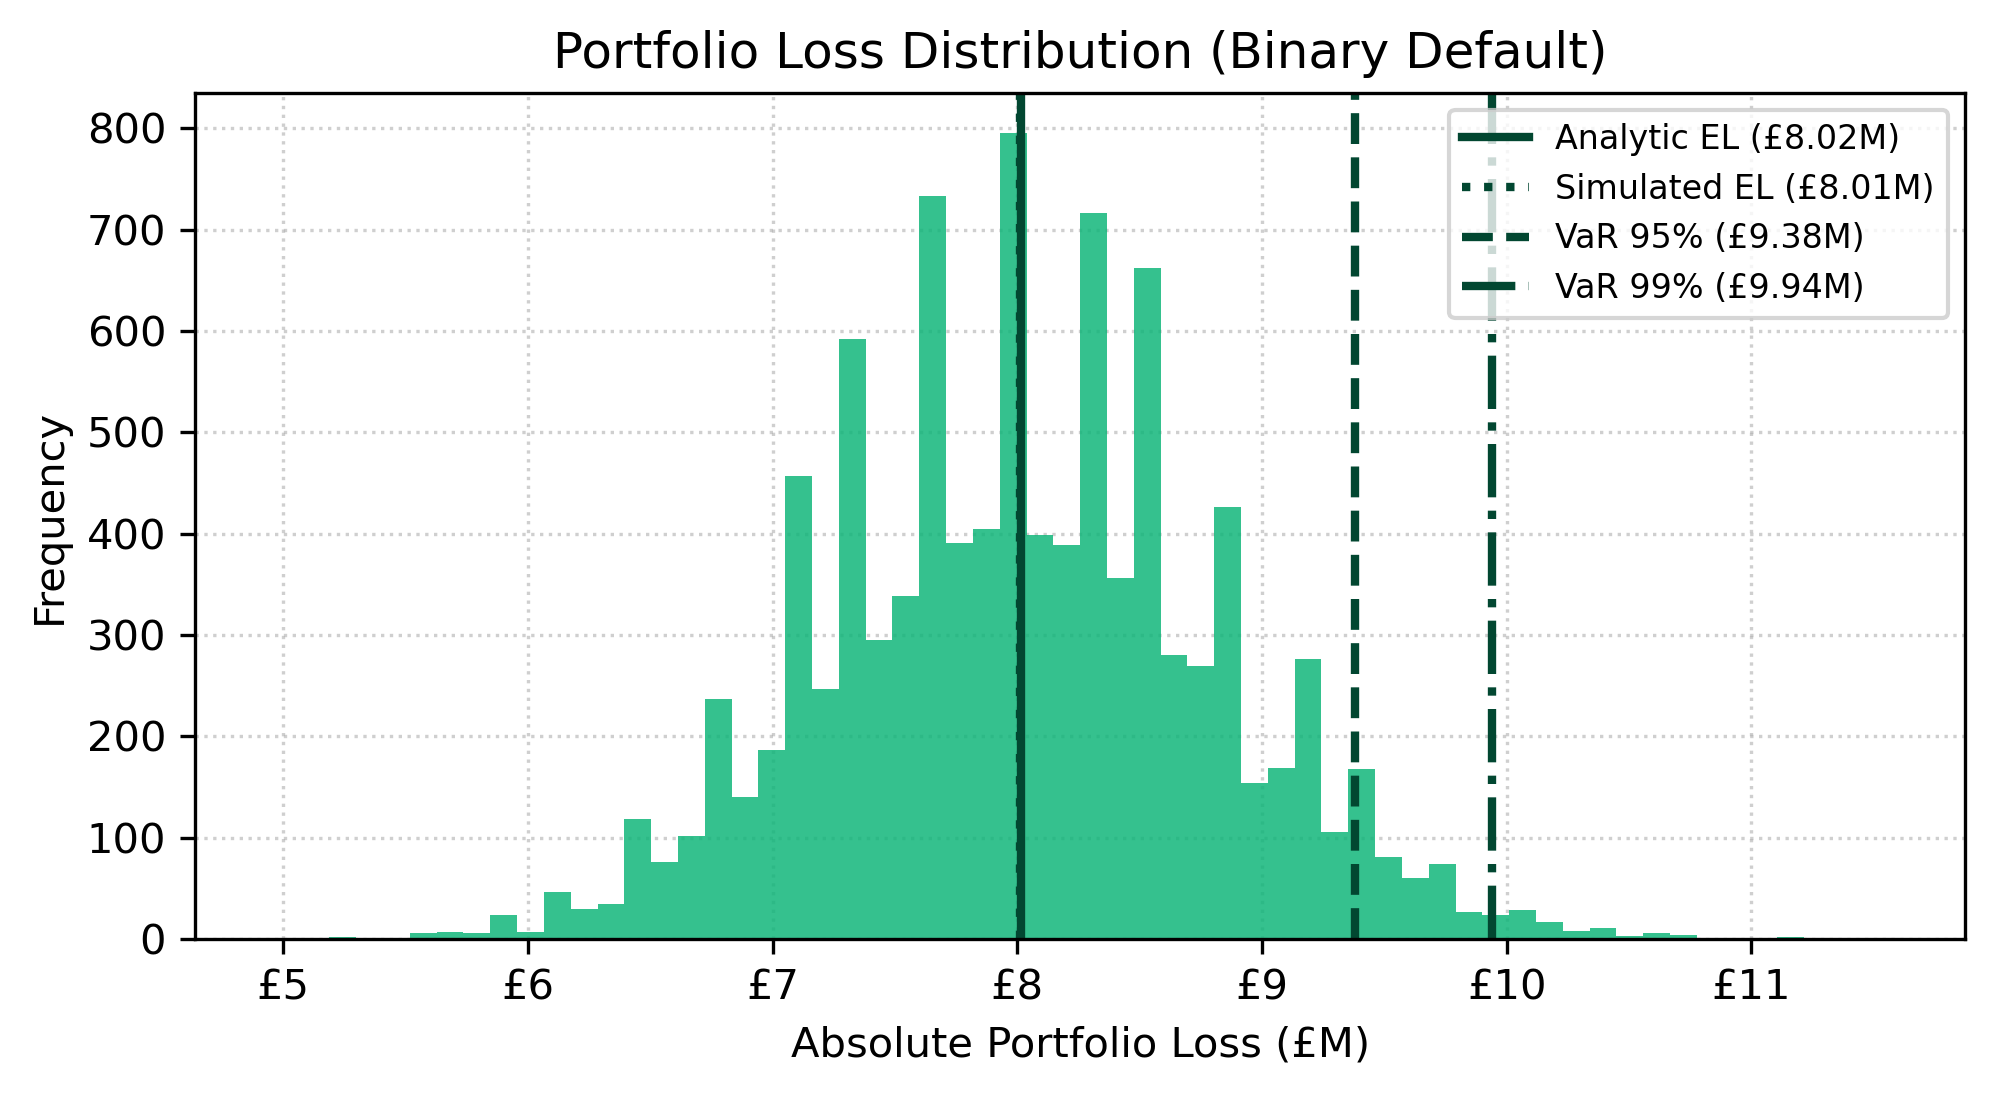

In [2]:
"""
The following generates loan level CVaRs under the original binary model. This code is recycled in BookGenerator.ipynb
"""

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from tqdm import tqdm

# Corporate color scheme variables
everyday_green = '#11B67A'
racing_green = '#024731'

class BinaryCVaRSimulator:

    def __init__(self):
        self.portfolio_df = None
        self.cov = None
        self.C = None
        self.losses = None          # Absolute portfolio losses per scenario
        self.all_loan_losses = None # Absolute loan-level losses per scenario (Tail only)
        self._analytic_el_val = 0.0

    def _make_pd(self, cov, eps=1e-8):
        cov = (cov + cov.T) / 2
        lam_min = np.linalg.eigvalsh(cov).min()
        delta = max(0.0, -lam_min + eps)
        return cov + delta * np.eye(cov.shape[0])
    
    def _chol_from_cov(self, cov, eps=1e-8):
        cov_pd = self._make_pd(cov, eps=eps)
        C = np.linalg.cholesky(cov_pd)
        return cov_pd, C

    def _build_factor_loadings(self, factor_index, M, N, C):
        F = np.zeros((M, N), dtype=float)
        for i, (_, row) in enumerate(self.portfolio_df[['region', 'sector']].iterrows()):
            F[i, factor_index[row['region']]] = 1.0
            F[i, factor_index[row['sector']]] = 1.0
        FC = F @ C
        row_norms = np.linalg.norm(FC, axis=1, keepdims=True)
        return FC / row_norms

    def simulate_losses(
        self,
        loan_book,
        pd_mapping,
        factor_index,
        cov,
        n_scenarios=100000,
        chunk=1000,
        seed=42
    ):
        # 1. Data Prep
        if 'loan_id' in loan_book.iloc[0].values:
            loan_book = loan_book.copy()
            loan_book.columns = loan_book.iloc[0]
            loan_book = loan_book.drop(loan_book.index[0]).reset_index(drop=True)
            
        for col in ['ead', 'lgd', 'rsq']:
            if col in loan_book.columns:
                loan_book[col] = pd.to_numeric(loan_book[col], errors='coerce')

        # Merge PDs if not explicitly in the loan book
        if 'pd' not in loan_book.columns:
            left_col = 'credit_rating'
            right_col = 'Credit Rating' if 'Credit Rating' in pd_mapping.columns else 'credit_rating'
            loan_book = pd.merge(loan_book, pd_mapping, left_on=left_col, right_on=right_col, how='left')
            # Ensure the merged column is named 'pd'
            if 'PD' in loan_book.columns and 'pd' not in loan_book.columns:
                loan_book.rename(columns={'PD': 'pd'}, inplace=True)
                
        self.portfolio_df = loan_book.reset_index(drop=True)
        self.cov, self.C = self._chol_from_cov(np.asarray(cov, float))
        
        M = len(self.portfolio_df)
        N = len(factor_index)

        # 2. Extract Vectors for Binary Simulation
        ead = self.portfolio_df['ead'].to_numpy()
        lgd = self.portfolio_df['lgd'].to_numpy()
        pd_array = self.portfolio_df['pd'].to_numpy()
        rsq = self.portfolio_df['rsq'].to_numpy()
        
        # Loss given default (Weight)
        weight = (ead * lgd)[:, None]
        
        # Calculate single default threshold per loan
        thr = norm.ppf(np.clip(pd_array, 1e-12, 1.0 - 1e-12))[:, None]
        
        # Calculate Analytic EL for the baseline
        self._analytic_el_val = float(np.sum(pd_array * ead * lgd))

        sqrt_rsq = np.sqrt(np.clip(rsq, 0.0, 1.0))[:, None]
        FC_hat = self._build_factor_loadings(factor_index, M, N, self.C)

        # --- PASS 1: Generate the full portfolio-level losses vector ---
        rng = np.random.default_rng(seed)
        losses_out = np.empty(n_scenarios)
        filled = 0

        with tqdm(total=n_scenarios, desc='Pass 1/2: Simulating Binary Defaults') as pbar:
            while filled < n_scenarios:
                s = min(chunk, n_scenarios - filled)
                sl = slice(filled, filled + s)

                Z = rng.standard_normal(size=(N, s))
                Y = FC_hat @ Z
                Xi = rng.standard_normal(size=(M, s))
                X = sqrt_rsq * Y + np.sqrt(1.0 - sqrt_rsq ** 2) * Xi 

                # Binary default condition
                defaults = (X <= thr)
                chunk_losses = defaults * weight
                losses_out[sl] = chunk_losses.sum(axis=0)
                
                filled += s
                pbar.update(s)

        self.losses = pd.Series(losses_out)
        
        # --- PASS 2: Extract tail coordinates and isolate loan-level losses ---
        var_threshold = float(np.quantile(losses_out, 0.99))
        tail_indices = np.where(losses_out >= var_threshold)[0]
        
        self.all_loan_losses = np.empty((M, len(tail_indices)))
        
        rng = np.random.default_rng(seed)
        filled = 0
        tail_saved_count = 0

        with tqdm(total=n_scenarios, desc='Pass 2/2: Mapping Loan Tail Risks') as pbar:
            while filled < n_scenarios:
                s = min(chunk, n_scenarios - filled)
                
                Z = rng.standard_normal(size=(N, s))
                Y = FC_hat @ Z
                Xi = rng.standard_normal(size=(M, s))
                X = sqrt_rsq * Y + np.sqrt(1.0 - sqrt_rsq ** 2) * Xi 

                defaults = (X <= thr)
                chunk_losses = defaults * weight

                current_tail_scenarios = tail_indices[(tail_indices >= filled) & (tail_indices < filled + s)]
                local_tail_indices = current_tail_scenarios - filled

                if len(local_tail_indices) > 0:
                    num_found = len(local_tail_indices)
                    self.all_loan_losses[:, tail_saved_count : tail_saved_count + num_found] = chunk_losses[:, local_tail_indices]
                    tail_saved_count += num_found

                filled += s
                pbar.update(s)

        return self.losses

    def analytic_EL(self):
        return self._analytic_el_val

    def var_quantile(self, alpha=0.99):
        return float(np.quantile(self.losses.to_numpy(), alpha))

    def expected_shortfall(self, alpha=0.99):
        arr = self.losses.to_numpy()
        q = np.quantile(arr, alpha)
        tail = arr[arr >= q]
        return float(tail.mean()) if len(tail) > 0 else float(q)

    def plot_loss_distribution(self):
        arr = self.losses.to_numpy()
        scale = 1_000_000.0

        fig, ax = plt.subplots(figsize=(6.75, 3.75), dpi=300)
        ax.hist(arr / scale, bins=60, color=everyday_green, edgecolor=None, alpha=0.85)

        ax.axvline(self.analytic_EL() / scale, color=racing_green, lw=2, label=f'Analytic EL (£{self.analytic_EL()/scale:,.2f}M)')
        ax.axvline(arr.mean() / scale, color=racing_green, lw=2, ls=':', label=f'Simulated EL (£{arr.mean()/scale:,.2f}M)')
        ax.axvline(self.var_quantile(0.95) / scale, color=racing_green, lw=2, ls='--', label=f'VaR 95% (£{self.var_quantile(0.95)/scale:,.2f}M)')
        ax.axvline(self.var_quantile(0.99) / scale, color=racing_green, lw=2, ls='-.', label=f'VaR 99% (£{self.var_quantile(0.99)/scale:,.2f}M)')

        ax.set_title('Portfolio Loss Distribution (Binary Default)')
        ax.set_xlabel('Absolute Portfolio Loss (£M)')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_axisbelow(True)
        ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('£{x:,.0f}'))
        fig.tight_layout()
        return fig

    def run_tail_analysis_and_export(self, alpha=0.99, output_filename='loan_level_cvar_binary.csv'):
        print("\nProcessing loan-level calculations across captured tail scenarios...")
        loan_cvars_raw = self.all_loan_losses.mean(axis=1)
        
        scale_to_millions = 1_000_000
        loan_cvars_millions = loan_cvars_raw 
        portfolio_cvar_millions = self.expected_shortfall(alpha) / scale_to_millions
        
        # The sum of individual loan CVaRs
        sum_of_parts = loan_cvars_millions.sum()

        attribution_df = pd.DataFrame({
            'loan_id': self.portfolio_df['loan_id'].to_numpy(),
            'loan_level_CVaR_(£)': loan_cvars_millions
        })
        
        attribution_df.to_csv(output_filename, index=False)
        print(f"Success! Exported loan risk distribution sheet to: '{output_filename}'")
        
        return attribution_df

# ==========================================
# Execution Block
# ==========================================

# 1. Load workspace files
systematic_shocks = pd.read_csv('systematic_shocks.csv', index_col='Quarter')
cov = systematic_shocks.cov()
factors = list(cov.columns)
factor_index = {name: j for j, name in enumerate(factors)}

raw_loan_book = pd.read_csv('LoanTest14(90norsq).csv') 
pd_mapping = pd.read_csv('pd_mapping.csv')

# 2. Execute Simulation
sim = BinaryCVaRSimulator()
sim.simulate_losses(
    loan_book=raw_loan_book,
    pd_mapping=pd_mapping,
    factor_index=factor_index,
    cov=cov,
    n_scenarios=10000,
    chunk=1000 
)

portfolio = sim.portfolio_df

# 3. Output metrics
print(f"Analytic EL: £{sim.analytic_EL()/1e6:.4f}m")
print(f"Simulated EL: £{sim.losses.mean()/1e6:.4f}m")
print(f"VaR (99%): £{sim.var_quantile(0.99)/1e6:.4f}m")
print(f"VaR (95%): £{sim.var_quantile(0.95)/1e6:.4f}m")
print(f"Expected Shortfall (99%): £{sim.expected_shortfall(0.99) / 1e6:.4f}m")

# 4. Final Output Generation
fig = sim.plot_loss_distribution()
cvar_matrix = sim.run_tail_analysis_and_export(alpha=0.99, output_filename='Test14results.csv')
plt.show()